# 🐍 Python Level 2 - Intermediate course
## Class 1 — Functions

**Python instructor - Fábio Moreira and Luis Dias**

---

<div style="display:inline-flex; align-items:center; gap:28px; background:#FFFFFF; color:#1D1D1B; padding:10px 14px; border-radius:8px; margin-bottom:8px;">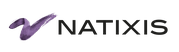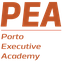</div>

---

---

### 📋 What we'll cover today

| # | Topic |
|---|-------|
| 1 | Why functions? |
| 2 | Defining and calling a function |
| 3 | Parameters, `return`, and docstrings |
| 4 | Default and keyword arguments |
| 5 | Local and global — where a variable lives |
| 6 | Functions calling functions |
| 7 | 🔗 Putting it all together |

### 🎯 Learning outcomes

By the end of this class you will be able to:

- Write a function that takes values in and gives a result back
- Give parameters sensible defaults, and call a function readably
- Explain why a variable inside a function is invisible outside it
- Build a small pipeline by having functions call each other

---

> 💡 **Welcome to Level 2.** In Level 1 you learned the pieces of the language. From here on it
> is about writing code you can *reuse* and that starts with giving a name to a job.

---
## 1. Why functions?

At the end of Level 1 you wrote a report: for each department, work out a percentage, decide a
status, print a line. It worked. But the *rule* for deciding the status lived in the middle of
the loop, so if you wanted the same rule anywhere else, your only option was to copy it.

Here is that problem in miniature. Two orders, and the same three steps written out twice:

- tidy up the customer's name
- work out the line total
- decide whether the order is small, medium or large

Watch how much of the second half is just the first half again.

In [ ]:
# ── The tangled version - the same three steps, written twice ─────────────
name = "  Ana Silva "
total = 8.50 * 3
if total > 100:
    size = "large"
elif total > 25:
    size = "medium"
else:
    size = "small"
print(name.strip().lower(), round(total, 2), size)

In [ ]:
name = " BRUNO COSTA"
total = 12.00 * 12
if total > 100:
    size = "large"
elif total > 25:
    size = "medium"
else:
    size = "small"
print(name.strip().lower(), round(total, 2), size)

Three problems, and they get worse with every order you add:

| Problem | Why it hurts |
|---------|-------------|
| The rule is written twice | Change the limits and you must remember to change both |
| It cannot be reused | Another notebook cannot borrow it — only copy it |
| It cannot be tested | You can't check the rule on its own, only by running everything |

A **function** fixes all three. You give the job a **name** once, and from then on you call the
name. Below is the same work, with the rule written **once**:

In [ ]:
# ── The same work, with each job given a name ─────────────────────────────
def classify_size(total):
    if total > 100:
        return "large"
    elif total > 25:
        return "medium"
    else:
        return "small"

In [ ]:
# Let's test the function with a simple input
classify_size(3)

In [ ]:
orders = [
    {"name": "  Ana Silva ", "price": 8.50, "quantity": 3},
    {"name": " BRUNO COSTA", "price": 12.00, "quantity": 12},
]

In [ ]:
for order in orders:
    total = round(order["price"] * order["quantity"], 2)
    print(order["name"].strip().lower(), total, classify_size(total))

---
## 2. Defining and calling a function

**The output of those two cells is identical** that is the point. Nothing about the result
changed; only the shape of the code did. The rule now exists in exactly one place, adding a
third order costs one line of *data* rather than another copy of the logic, and if the limits
change you edit one function. So let's look properly at how you make one.

You **define** a function with `def`, and nothing happens until you **call** it.

```
   def classify_size(total):
       └──────┬─────┘ └─┬─┘
            name     parameter
```

Three rules:

- `def`, the name, brackets, then a **colon**
- everything belonging to the function is **indented** underneath. Same rule as `if` and `for`
- defining it only teaches Python the job. `classify_size(50)` is what does it

> ⚠️ `classify_size` without brackets is the function *itself*; `classify_size(50)` **runs** it.
> Printing the first gives you something like `<function classify_size at 0x...>`, which is
> Python telling you that you forgot the brackets.

In [ ]:
# Defining it - nothing happens yet
def show_header():
    print("ORDER REPORT")
    print("-" * 24)

In [ ]:
# Calling it - now it runs, and we can call it as often as we like
show_header()

In [ ]:
show_header()

In [ ]:
print(show_header)     # without brackets: the function itself, not its result

---
## 3. Parameters, `return`, and docstrings

### Parameters — values you hand in

A **parameter** is a name the function uses for something you give it. It exists only inside
the function.

### `return` — the value you get back

`return` sends a value out of the function, and **stops it immediately**. Anything after a
`return` that has run never happens.

> ⚠️ `print()` and `return` are not the same thing. `print()` shows a value on screen;
> `return` hands it back so you can *use* it. A function that only prints gives back `None`,
> so `total = shout("hi")` leaves `total` as `None`.

### Docstrings — saying what the function is for

A string on the first line inside a function is a **docstring**: a one-line description of
what it does. It is not a comment since Python keeps it, and `help(your_function)` will show it.

In [ ]:
def line_total(price, quantity):
    """Return the total for one order line, rounded to 2 decimals."""
    return round(price * quantity, 2)

In [ ]:
total = line_total(8.50, 3)        # the returned value is handed back to us
print(total)

In [ ]:
print(line_total(12.00, 12) + line_total(2.50, 4))   # usable straight away

In [ ]:
# A function that only prints gives back None
def shout(text):
    """Print text in capitals."""
    print(text.upper())

In [ ]:
result = shout("done")

In [ ]:
print(result)                      # None - shout() printed, it returned nothing

---
## 4. Default and keyword arguments

### Default arguments

Give a parameter a default with `=`, and the caller may leave it out.

```
   def line_total(price, quantity=1):
```

Now `line_total(8.50)` works and treats the quantity as 1. Defaults are for the *usual* case,
so the caller only mentions what is unusual.

> ⚠️ Parameters **with** defaults must come after those without. `def f(quantity=1, price)` is
> an error.

### Keyword arguments

Normally Python matches your values to parameters **by position**. You can instead name them,
and then the order stops mattering:

| Call | Reads as |
|------|----------|
| `line_total(8.50, 3)` | fine, but which number is which? |
| `line_total(price=8.50, quantity=3)` | obvious |
| `line_total(quantity=3, price=8.50)` | also fine — names beat order |

> 💡 Use keyword arguments as soon as a function takes more than two values, or takes two of
> the same type. `discount(100, 20)` is a guess; `discount(amount=100, percent=20)` is not.

In [ ]:
def line_total(price, quantity=1, discount_percent=0):
    """Return the total for one line, after any discount."""
    total = price * quantity
    total = total - (total * discount_percent / 100)
    return round(total, 2)

In [ ]:
print(line_total(8.50))                                  # quantity 1, no discount

In [ ]:
print(line_total(8.50, 3))                               # by position

In [ ]:
print(line_total(price=8.50, quantity=3))                # by name - clearer

In [ ]:
print(line_total(quantity=3, price=8.50))                # order stops mattering

In [ ]:
print(line_total(price=8.50, quantity=3, discount_percent=10))

---
## 5. Local and global — where a variable lives

A variable created **inside** a function exists only while that function runs, and only in
there. It is **local**. When the function ends, it is gone.

A variable created **outside** every function is **global** and any function can read it.

```
   discount_rate = 10      global - any function can read it
   │
   ├── def apply_discount(amount):
   │       saving = ...     local - gone when the call ends
   │       return ...
   │
   └── print(saving)        error - saving does not exist here
```

This is a feature, not a nuisance. It means a function cannot quietly break the rest of your
notebook by reusing a common name like `total` or `i`.

> 💡 The habit worth forming: **pass values in as parameters, and hand results back with
> `return`.** A function that reads globals works until someone renames one; a function that
> takes what it needs keeps working anywhere.

In [ ]:
discount_rate = 10          # global - defined outside every function

def apply_discount(amount):
    """Take the standard discount off an amount."""
    saving = amount * discount_rate / 100    # reads the global, makes a local
    return round(amount - saving, 2)

In [ ]:
print(apply_discount(200))       # 180.0

In [ ]:
print(discount_rate)             # 10 - untouched

In [ ]:
# print(saving)   <- error: 'saving' only existed inside the function

# A local name does not disturb a global one, even with the same name
amount = 999

def double(amount):
    """Return twice what it is given."""
    amount = amount * 2          # this 'amount' is local to double()
    return amount

In [ ]:
print(double(4))                 # 8

In [ ]:
print(amount)                    # 999 - the outer one never changed

---
## 6. Functions calling functions

A function can call another function. This is how you build something real: several small
functions that each do one job, and one function that puts them in order.

Each step stays small enough to understand on its own and small enough to fix on its own.

```
   one order (a dict)
        │
        ▼
   tidy_name()          make the name presentable
        │
        ▼
   line_total()         work out the money
        │
        ▼
   classify_size()      small / medium / large
        │
        ▼
   describe_order()     puts the three together
        │
        ▼
   one finished line of the report
```

In [ ]:
def tidy_name(name):
    """Remove stray spaces from a name."""
    return name.strip()

In [ ]:
def line_total(price, quantity=1):
    """Return the total for one line, rounded to 2 decimals."""
    return round(price * quantity, 2)

In [ ]:
def classify_size(total):
    """Label an order small, medium or large."""
    if total > 100:
        return "large"
    elif total > 25:
        return "medium"
    else:
        return "small"

In [ ]:
def describe_order(order):
    """Build one report line, using the three helpers above."""
    name = tidy_name(order["name"])
    total = line_total(order["price"], order["quantity"])
    size = classify_size(total)
    return f"{name:<14}{total:>8.2f} EUR   {size}"

In [ ]:
print(describe_order({"name": "  Ana Silva ", "price": 8.50, "quantity": 3}))

In [ ]:
print(describe_order({"name": "Bruno Costa", "price": 12.00, "quantity": 12}))

---
## 7. 🔗 Putting it all together — order report

The Level 1 project as it should have been written: the same job, but every rule has a name.

### The situation

You have a list of today's orders. You need a printed report with one tidy line per order, and
a summary counting how many were small, medium and large plus the total value.

### What the program must do

1. Write `line_total()` and `classify_size()` — one job each
2. Write `describe_order()` to build one report line, calling both of them
3. Write `summarise_orders()` that loops the orders and **returns a dictionary** of the counts
   and the total — a function can hand back a whole dict, not just a number
4. Print the report, then the summary
5. Change one limit at the top and re-run, to see the whole report follow

### Where each concept appears

| Concept from today | Where it is used |
|--------------------|------------------|
| `def` and `return` | all four functions |
| Parameters | `price`, `quantity`, `total`, `orders` |
| Default argument | `quantity=1` in `line_total()` |
| Keyword arguments | the call to `line_total()` inside `describe_order()` |
| Docstrings | one line at the top of each function |
| Local variables | `total`, `size`, `counts` — none of them leak out |
| Functions calling functions | `describe_order()` and `summarise_orders()` |
| Returning a dict | `summarise_orders()` |
| `dict`, `for`, `if`, `+=`, f-strings | from Level 1 |

In [ ]:
# ── The rules, each with a name ────────────────────────────────────────────
SMALL_LIMIT = 25       # up to here it is small
LARGE_LIMIT = 100      # above here it is large


def line_total(price, quantity=1):
    """Return the total for one line, rounded to 2 decimals."""
    return round(price * quantity, 2)

In [ ]:
def classify_size(total):
    """Label an order small, medium or large."""
    if total > LARGE_LIMIT:
        return "large"
    elif total > SMALL_LIMIT:
        return "medium"
    else:
        return "small"

In [ ]:
def describe_order(order):
    """Build one line of the report for a single order."""
    total = line_total(price=order["price"], quantity=order["quantity"])
    return f"{order['name'].strip():<14}{total:>9.2f} EUR  {classify_size(total)}"

In [ ]:
def summarise_orders(orders):
    """Count the orders by size and total their value. Returns a dict."""
    counts = {"small": 0, "medium": 0, "large": 0}
    value = 0
    for order in orders:
        total = line_total(price=order["price"], quantity=order["quantity"])
        counts[classify_size(total)] += 1
        value += total
    counts["total_value"] = round(value, 2)
    return counts

In [ ]:
# ── The data ───────────────────────────────────────────────────────────────
orders = [
    {"name": "  Ana Silva ", "price": 8.50, "quantity": 3},
    {"name": "Bruno Costa", "price": 12.00, "quantity": 12},
    {"name": " Clara Dias", "price": 2.10, "quantity": 4},
    {"name": "Diogo Melo ", "price": 45.00, "quantity": 5},
]

In [ ]:
# ── The report ─────────────────────────────────────────────────────────────
print("ORDER REPORT")
print("-" * 44)
for order in orders:
    print(describe_order(order))

print("-" * 44)
summary = summarise_orders(orders)
for size in ["small", "medium", "large"]:
    print(f"{size:<14}{summary[size]:>9}")
print(f"{'total value':<14}{summary['total_value']:>9.2f} EUR")

---

### 🎉 That's Level 2 Class 1!

| Concept | Key syntax |
|---------|-----------|
| Define a function | `def line_total(price):` |
| Call it | `line_total(8.50)` |
| Hand a value back | `return round(price, 2)` |
| Describe it | `"""One line saying what it does."""` |
| Default argument | `def f(price, quantity=1):` |
| Keyword argument | `line_total(price=8.50, quantity=3)` |
| No return | gives back `None` |
| Local variable | created inside, invisible outside |
| Global variable | created outside, readable inside |
| One function calling another | `describe_order()` calls all three helpers |
| Return a whole dict | `return counts` |

> 💡 **The test of a good function:** you can describe what it does in one sentence, without
> the word "and". `classify_size()` labels an order. A function that cleans the name
> *and* totals the line *and* labels it should be three functions.

➡️ Now open the **exercises notebook**.